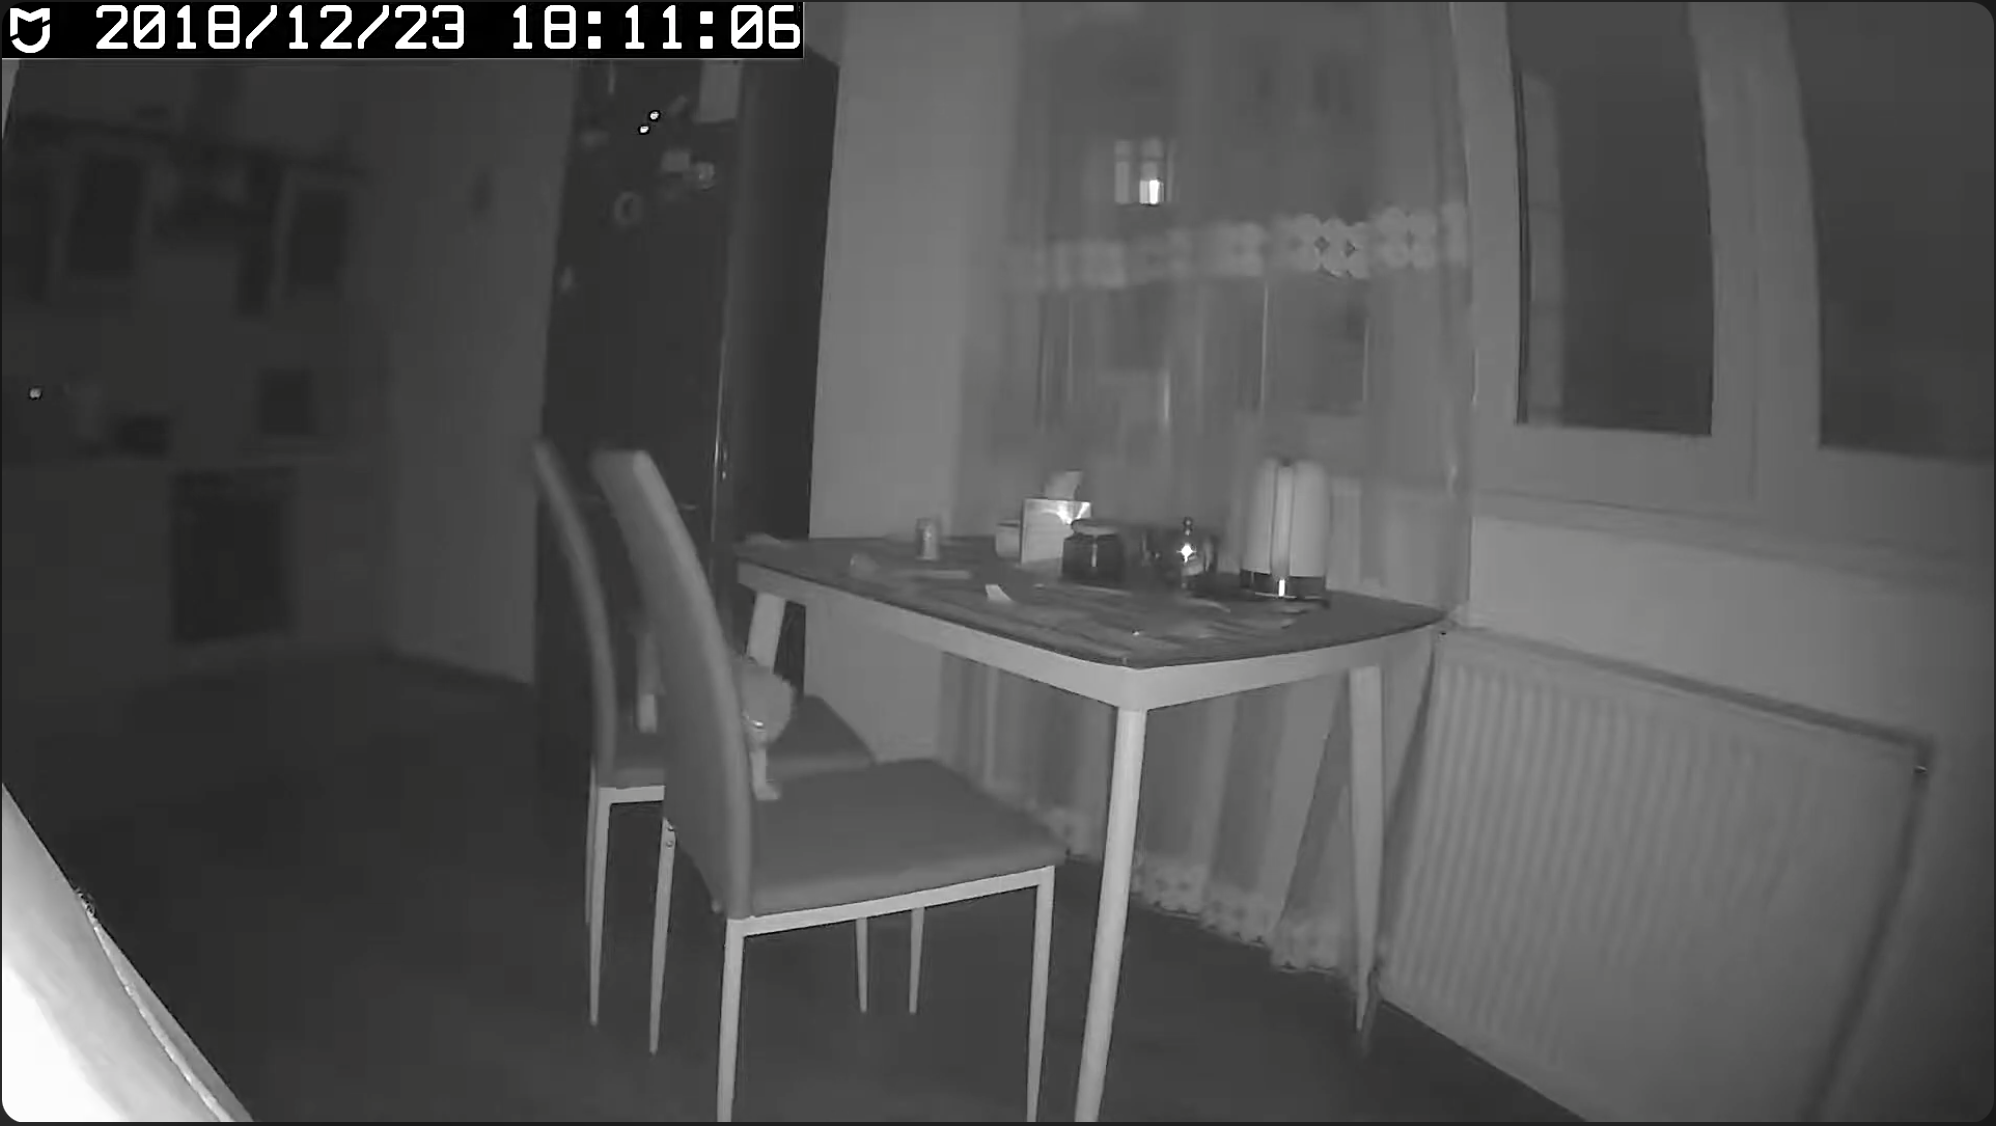

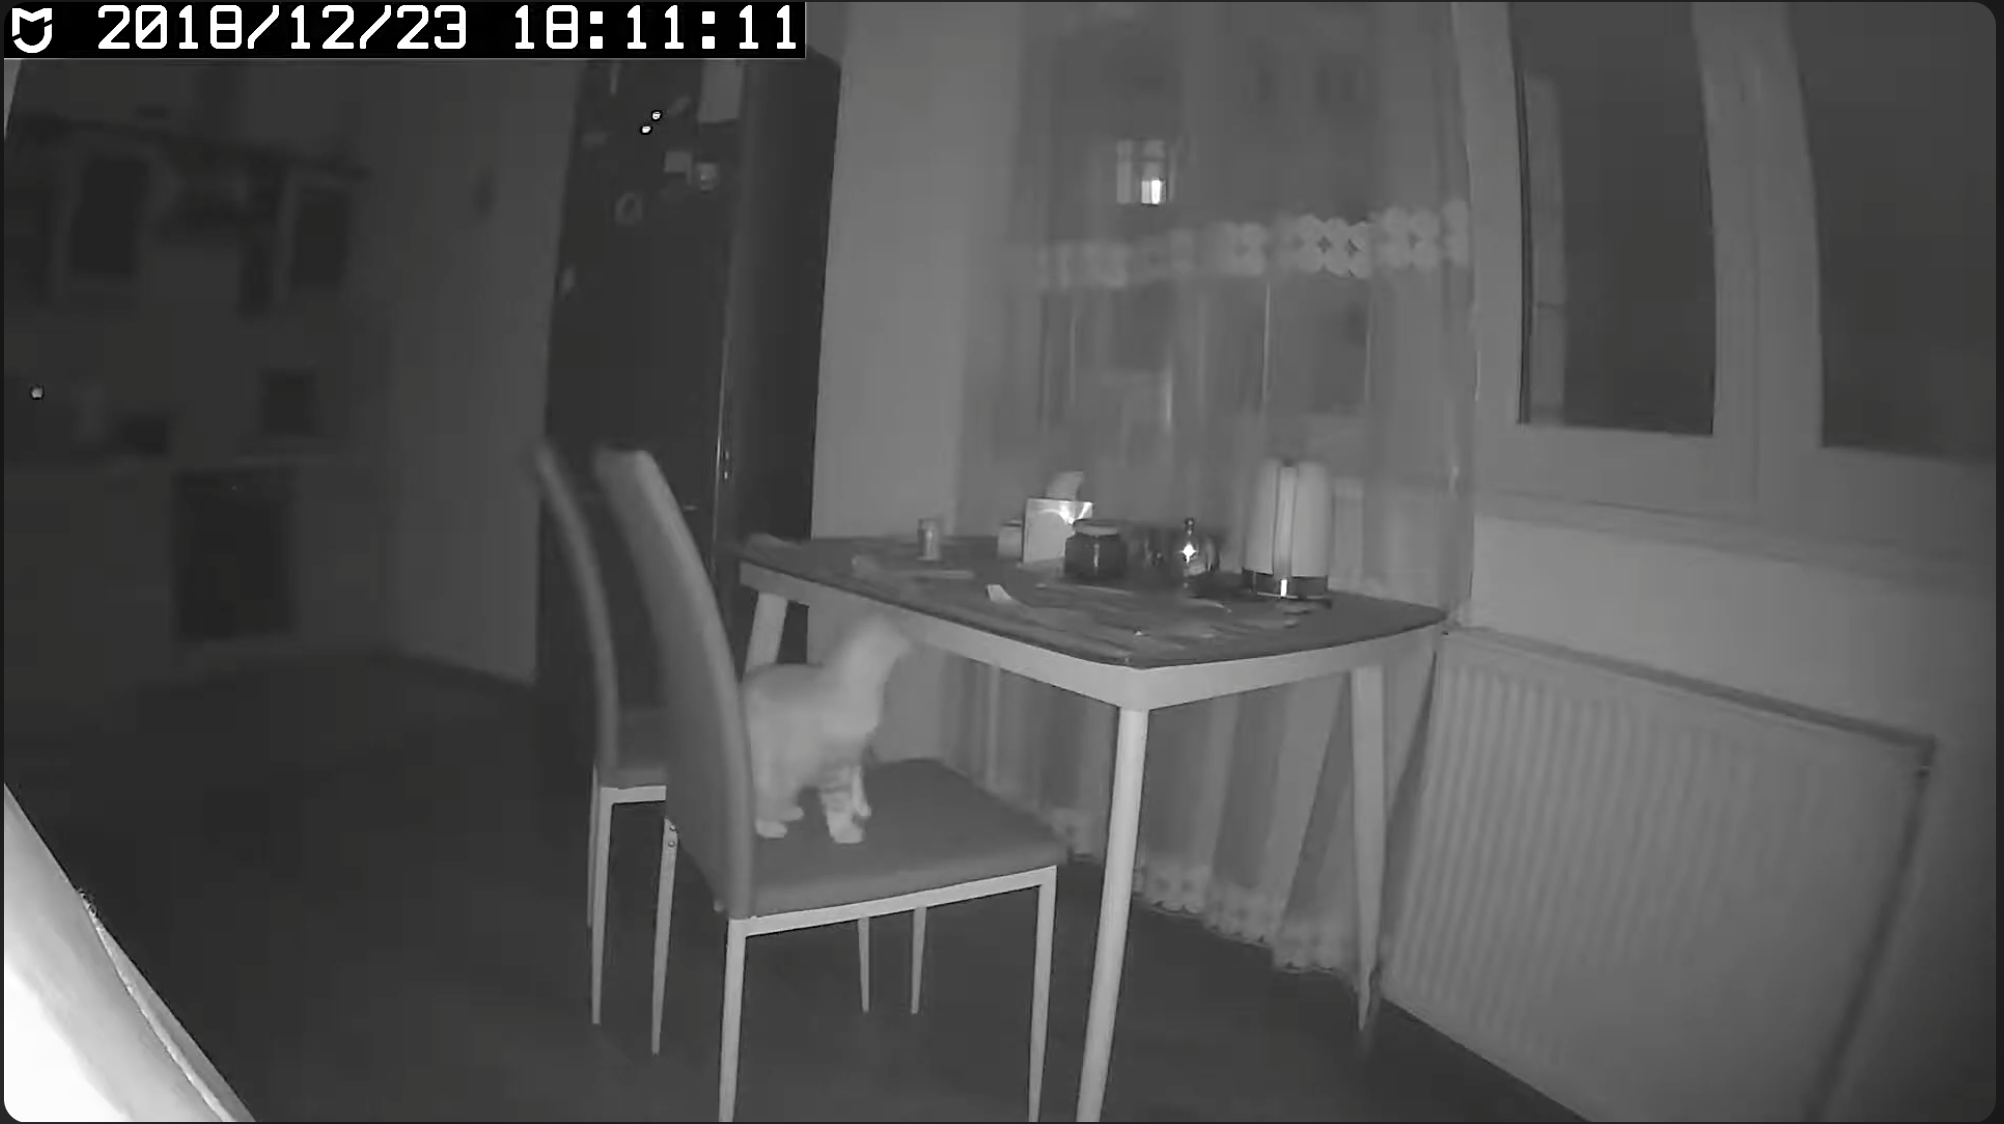

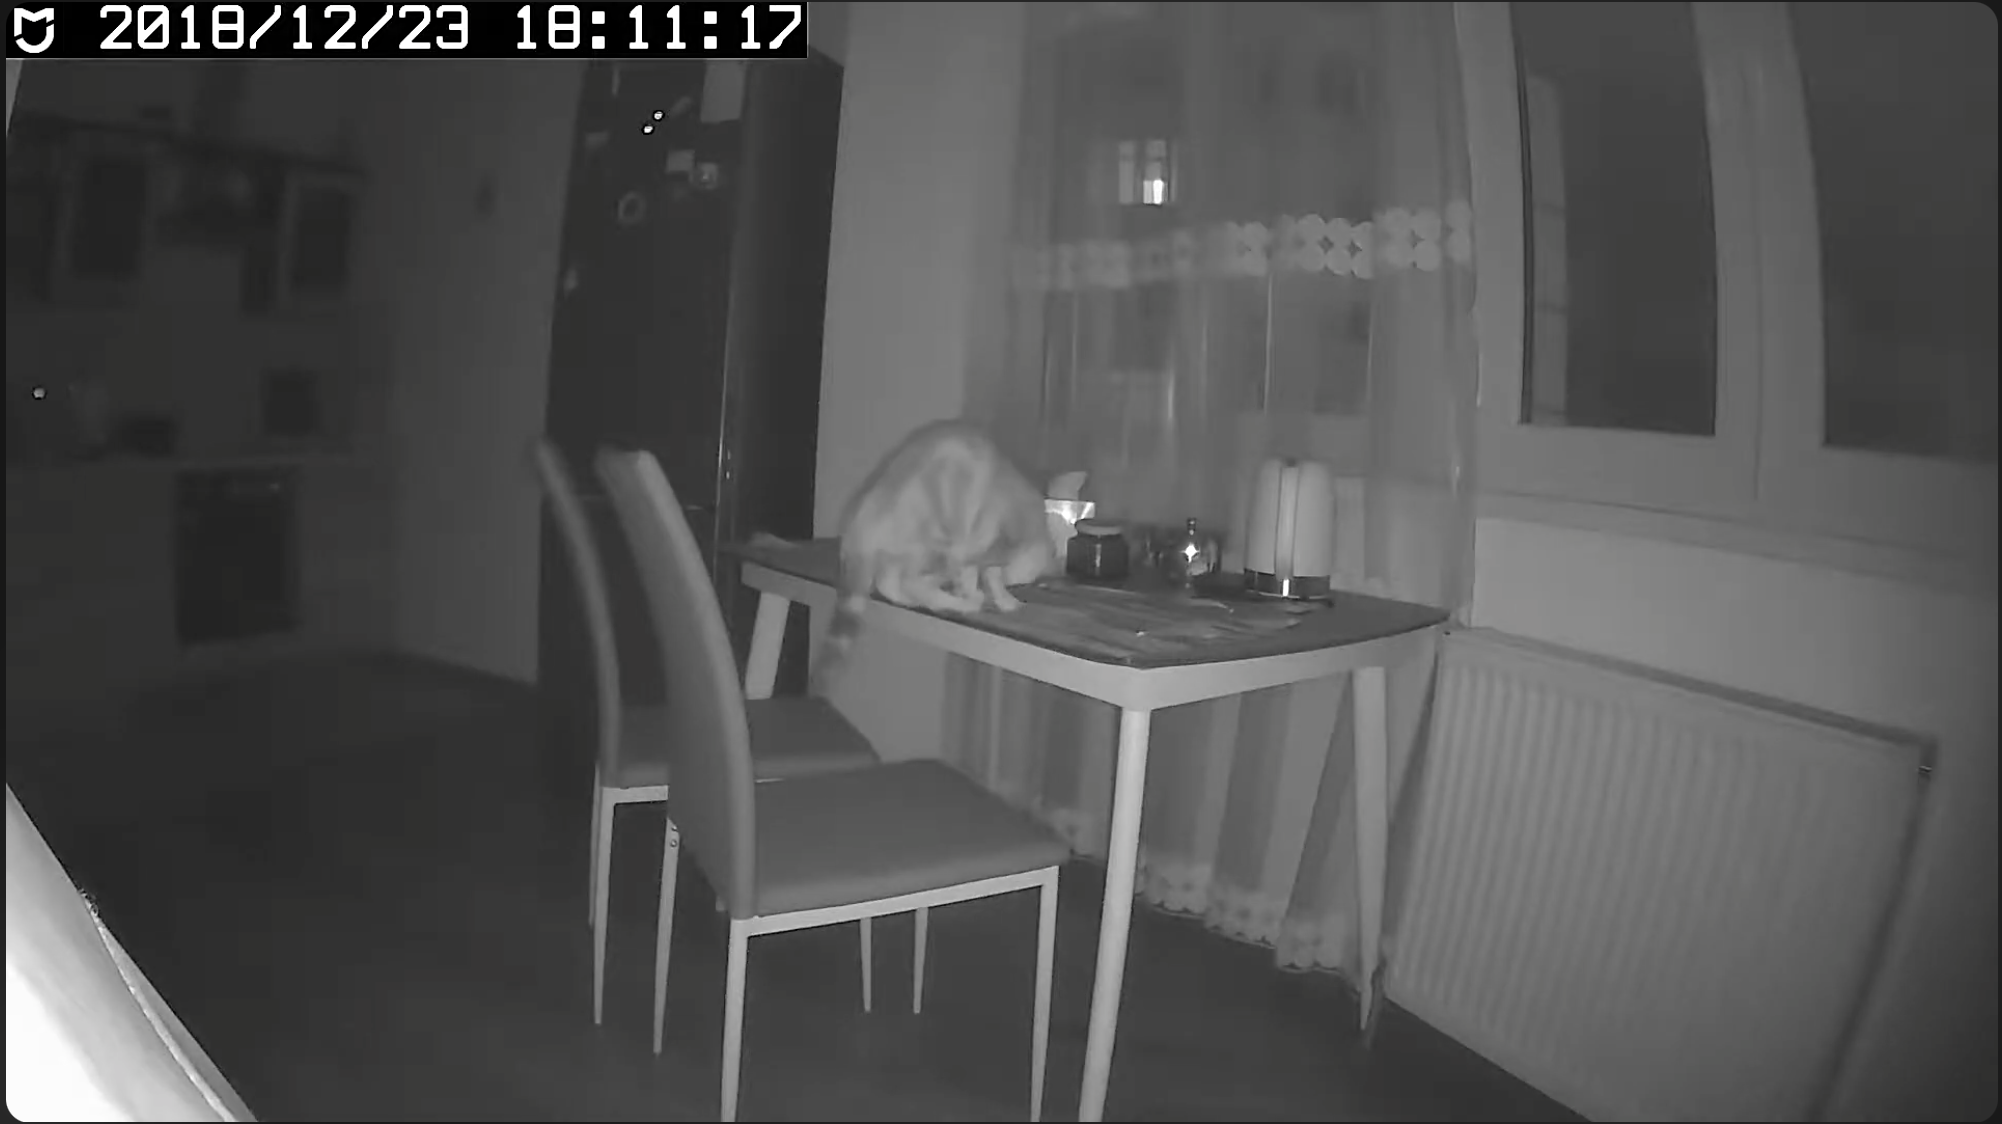

In [1]:
from pathlib import Path

from IPython.display import Image, display

data_dir = Path('data') if Path('data').is_dir() else Path('../data')
images = [Image(filename=str(path), width=800) for path in sorted(data_dir.glob('*.png'))]

for image in images:
    display(image)

In [2]:
import sys

from google import genai
from google.genai import types

sys.path.insert(0, str(data_dir.resolve().parent))
from src.config import GEMINI_API_KEY

client = genai.Client(api_key=GEMINI_API_KEY)

In [6]:
SYSTEM_PROMPT = (
    "Ты сравниваешь два кадра с камеры наблюдения: первый снят раньше, второй позже.\n"
    "Найди отличия между кадрами и реши, произошло ли на втором кадре событие, "
    "которое описал пользователь.\n"
    "Правила:\n"
    "- Событие засчитывается, только если на первом кадре его ещё нет, а на втором уже есть.\n"
    "- Обратное изменение (было на первом, пропало на втором) событием не считается.\n"
    "- Отличия, не относящиеся к запросу пользователя, игнорируй.\n"
    "- Если не уверен — false.\n"
    "Ответь ровно одним словом: true или false."
)

In [7]:
# что просит отслеживать пользователь — обычной фразой
user_query = "кот залез на стол (кот на стуле не считается)"

In [53]:
from concurrent.futures import ThreadPoolExecutor
from io import BytesIO
from statistics import median
from time import perf_counter, sleep

from google.genai.errors import ServerError
from PIL import Image, ImageChops, ImageStat

MODEL = "gemini-3.1-flash-lite"  # см. сравнение 5: та же точность, медиана 2.4s против 9.9s
MAX_WIDTH = 640  # исходники ~2000px; на токены не влияет, но грузится втрое легче
QUALITY = 85
DIFF_THRESHOLD = 0.5  # средняя разница пикселей, ниже — считаем кадры одинаковыми
RETRIES = 3  # 503 "high demand" ловится регулярно, особенно при параллельных запросах


def _load(name: str) -> Image.Image:
    """PNG с камеры -> серый, ужатый по ширине."""
    image = Image.open(data_dir / name).convert("L")
    if image.width > MAX_WIDTH:
        image = image.resize((MAX_WIDTH, round(image.height * MAX_WIDTH / image.width)))
    return image


def _jpeg(image: Image.Image) -> bytes:
    buffer = BytesIO()
    image.save(buffer, "JPEG", quality=QUALITY)
    return buffer.getvalue()


def _glue(first: Image.Image, second: Image.Image, gap: int = 8) -> Image.Image:
    """Два кадра в одну картинку: слева раньше, справа позже."""
    canvas = Image.new("L", (first.width + gap + second.width, max(first.height, second.height)), 255)
    canvas.paste(first, (0, 0))
    canvas.paste(second, (first.width + gap, 0))
    return canvas


def diff_score(first: Image.Image, second: Image.Image) -> float:
    """Средняя разница пикселей. Дешёвый фильтр перед походом в API."""
    return round(ImageStat.Stat(ImageChops.difference(first, second)).mean[0], 2)


def ask(query: str, first: str, second: str, glue: bool = True) -> dict:
    """Случилось ли событие `query` между кадрами first -> second."""
    a, b = _load(first), _load(second)

    # кадры не изменились — событию неоткуда взяться, API не трогаем
    score = diff_score(a, b)
    if score < DIFF_THRESHOLD:
        return {"answer": "false", "seconds": 0.0, "prompt_tokens": 0, "diff": score, "skipped": True}

    if glue:
        blobs = [_jpeg(_glue(a, b))]
        query = f"{query}\n(кадры склеены в одну картинку: слева — первый, справа — второй)"
    else:
        blobs = [_jpeg(a), _jpeg(b)]

    started = perf_counter()
    # 503 UNAVAILABLE ("high demand") на параллельных запросах — обычное дело, ждём и повторяем
    for attempt in range(RETRIES):
        try:
            response = client.models.generate_content(
                model=MODEL,
                contents=[query, *(types.Part.from_bytes(data=b_, mime_type="image/jpeg") for b_ in blobs)],
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    thinking_config=types.ThinkingConfig(thinking_level="minimal"),
                    media_resolution=types.MediaResolution.MEDIA_RESOLUTION_LOW,
                ),
            )
            break
        except ServerError:
            if attempt == RETRIES - 1:
                raise
            sleep(1 + attempt)
    return {
        "answer": response.text.strip().lower(),
        "seconds": round(perf_counter() - started, 3),
        "prompt_tokens": response.usage_metadata.prompt_token_count,
        "diff": score,
        "skipped": False,
    }

In [55]:
display(ask(user_query, "2.png", "3.png"))

{'answer': 'true',
 'seconds': 2.969,
 'prompt_tokens': 422,
 'diff': 3.66,
 'skipped': False}

In [54]:
# Проверка качества, а не только скорости.
# Разметка кадров: 1 — кот у стула, 2 — кот на стуле, 3 — кот на столе.
CASES = [
    ("1.png", "2.png", False),  # кот только на стуле — события нет
    ("2.png", "3.png", True),  # со стула на стол — событие
    ("1.png", "3.png", True),  # с пола на стол — событие
    ("3.png", "3.png", False),  # ничего не изменилось — отсекается локально
    ("3.png", "2.png", False),  # кот ушёл со стола — обратное изменение
]


def run_cases(workers: int = 1) -> int:
    started = perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(lambda c: ask(user_query, c[0], c[1]), CASES))
    wall = round(perf_counter() - started, 2)

    hits = 0
    for (first, second, expected), result in zip(CASES, results):
        ok = result["answer"] == str(expected).lower()
        hits += ok
        mark = "skip" if result["skipped"] else f"{result['seconds']}s, {result['prompt_tokens']} ток."
        print(f"{'ok  ' if ok else 'FAIL'} {first} -> {second}: {result['answer']} (ждали {expected}), diff={result['diff']}, {mark}")
    print(f"workers={workers}: {hits}/{len(CASES)} верных, всего {wall}s\n")
    return hits


run_cases(workers=1)
hits = run_cases(workers=5)
assert hits == len(CASES), "модель ошиблась хотя бы на одном кейсе"

ok   1.png -> 2.png: false (ждали False), diff=3.31, 4.116s, 422 ток.
ok   2.png -> 3.png: true (ждали True), diff=3.66, 3.208s, 422 ток.
ok   1.png -> 3.png: true (ждали True), diff=3.42, 1.224s, 422 ток.
ok   3.png -> 3.png: false (ждали False), diff=0.0, skip
ok   3.png -> 2.png: false (ждали False), diff=3.66, 2.924s, 422 ток.
workers=1: 5/5 верных, всего 12.3s

ok   1.png -> 2.png: false (ждали False), diff=3.31, 4.644s, 422 ток.
ok   2.png -> 3.png: true (ждали True), diff=3.66, 4.015s, 422 ток.
ok   1.png -> 3.png: true (ждали True), diff=3.42, 2.43s, 422 ток.
ok   3.png -> 3.png: false (ждали False), diff=0.0, skip
ok   3.png -> 2.png: false (ждали False), diff=3.66, 16.437s, 422 ток.
workers=5: 5/5 верных, всего 16.82s



## Сравнения — почему настройки именно такие

Ниже прогоны, на которых выбраны склейка, `media_resolution=LOW` и ширина кадра.
Все запросы параллельные: латентность у API бимодальная (≈1s или залипание на 20–70s),
последовательный прогон меряет не настройку, а хвост.

Что проверено и отброшено (в ноутбук не вошло, чтобы не жечь квоту):
дедлайн короче 10s API запрещает (`400: Minimum allowed deadline is 10s`);
хедж параллельными дублями не помогает — дубли залипают вместе;
пауза 30s между запросами ничего не меняет, значит это не троттлинг по частоте.

In [40]:
# Сравнение 1: склейка в одну картинку vs два отдельных кадра.


def raw_call(blobs: list[bytes], query: str, media_low: bool = True) -> tuple[str, int]:
    """Голый вызов без дифф-фильтра — нужен для сравнений."""
    config = dict(
        system_instruction=SYSTEM_PROMPT,
        thinking_config=types.ThinkingConfig(thinking_level="minimal"),
    )
    if media_low:
        config["media_resolution"] = types.MediaResolution.MEDIA_RESOLUTION_LOW
    response = client.models.generate_content(
        model=MODEL,
        contents=[query, *(types.Part.from_bytes(data=b, mime_type="image/jpeg") for b in blobs)],
        config=types.GenerateContentConfig(**config),
    )
    return response.text.strip().lower(), response.usage_metadata.prompt_token_count


def build(first: str, second: str, glue: bool) -> tuple[list[bytes], str]:
    a, b = _load(first), _load(second)
    if glue:
        return [_jpeg(_glue(a, b))], f"{user_query}\n(кадры склеены в одну картинку: слева — первый, справа — второй)"
    return [_jpeg(a), _jpeg(b)], user_query


def compare_glue(glue: bool) -> None:
    with ThreadPoolExecutor(max_workers=5) as pool:
        results = list(pool.map(lambda c: raw_call(*build(c[0], c[1], glue)), CASES))
    hits = sum(answer == str(expected).lower() for (_, _, expected), (answer, _) in zip(CASES, results))
    answers = [answer for answer, _ in results]
    print(f"{'склейка  ' if glue else 'два кадра'}: {hits}/{len(CASES)} верных, {results[0][1]} токенов, {answers}")


print("ждали:    ", [str(e).lower() for _, _, e in CASES])
compare_glue(glue=False)
compare_glue(glue=True)

ждали:     ['false', 'true', 'true', 'false', 'false']
два кадра: 5/5 верных, 680 токенов, ['false', 'true', 'true', 'false', 'false']
склейка  : 5/5 верных, 422 токенов, ['false', 'true', 'true', 'false', 'false']


In [41]:
# Сравнение 2: media_resolution. Единственная настройка, которая реально режет токены.
blobs, query = build("2.png", "3.png", glue=True)
for media_low in (False, True):
    answer, tokens = raw_call(blobs, query, media_low=media_low)
    print(f"media_resolution={'LOW    ' if media_low else 'default'}: {tokens} токенов, ответ {answer}")

media_resolution=default: 1245 токенов, ответ true
media_resolution=LOW    : 422 токенов, ответ true


In [42]:
# Сравнение 3: ширина кадра. Токены от неё не зависят — Gemini масштабирует у себя.
# Уменьшение экономит только заливку, поэтому MAX_WIDTH=640, а не 2000.
_original_width = MAX_WIDTH
for width in (1024, 640, 384):
    MAX_WIDTH = width
    blobs, query = build("2.png", "3.png", glue=True)
    answer, tokens = raw_call(blobs, query)
    print(f"width={width:5}: {len(blobs[0]) // 1024:3}KB на запрос, {tokens} токенов, ответ {answer}")
MAX_WIDTH = _original_width

width= 1024:  89KB на запрос, 422 токенов, ответ true
width=  640:  44KB на запрос, 422 токенов, ответ true
width=  384:  21KB на запрос, 422 токенов, ответ true


In [49]:
# Сравнение 4: задержка по моделям. Дедлайн 10s (меньше API не разрешает),
# что не уложилось — считаем таймаутом, иначе один хвост съедает весь прогон.
CANDIDATES = [
    "gemini-3.5-flash-lite",
    "gemini-3.1-flash-lite",
    "gemini-flash-lite-latest",
    "gemini-3.5-flash",
]
REPEATS = 5
blobs, query = build("2.png", "3.png", glue=True)


def timed_call(model: str) -> tuple[float, str | None, int | None, str | None]:
    """Один вызов с дедлайном. Вернёт (секунды, ответ, токены, ошибка)."""
    started = perf_counter()
    try:
        response = client.models.generate_content(
            model=model,
            contents=[query, *(types.Part.from_bytes(data=b, mime_type="image/jpeg") for b in blobs)],
            config=types.GenerateContentConfig(
                system_instruction=SYSTEM_PROMPT,
                media_resolution=types.MediaResolution.MEDIA_RESOLUTION_LOW,
                http_options=types.HttpOptions(timeout=10_000),
            ),
        )
        seconds = round(perf_counter() - started, 2)
        return seconds, response.text.strip().lower(), response.usage_metadata.prompt_token_count, None
    except Exception as error:
        # 504 DEADLINE_EXCEEDED — реально не успела; остальное (404 и т.п.) — не про скорость
        kind = "таймаут" if "DEADLINE_EXCEEDED" in str(error) else type(error).__name__
        return round(perf_counter() - started, 2), None, None, kind


for model in CANDIDATES:
    runs = [timed_call(model) for _ in range(REPEATS)]
    ok = sorted(seconds for seconds, answer, _, _ in runs if answer)
    errors = [kind for _, answer, _, kind in runs if not answer]
    tokens = next((t for _, answer, t, _ in runs if answer), None)
    answers = {answer for _, answer, _, _ in runs if answer}
    if ok:
        print(f"{model:26} уложились {len(ok)}/{REPEATS}, медиана {median(ok)}s, макс {max(ok)}s, {tokens} токенов, ответы {answers}")
    else:
        print(f"{model:26} ни разу: {set(errors)}")

gemini-3.5-flash-lite      уложились 2/5, медиана 2.305s, макс 3.25s, 422 токенов, ответы {'true'}
gemini-3.1-flash-lite      уложились 5/5, медиана 1.64s, макс 3.04s, 422 токенов, ответы {'true'}
gemini-flash-lite-latest   уложились 4/5, медиана 7.64s, макс 9.19s, 422 токенов, ответы {'true'}
gemini-3.5-flash           уложились 1/5, медиана 9.32s, макс 9.32s, 422 токенов, ответы {'true'}


In [50]:
# Сравнение 5: кандидат на замену. Быстрая модель бесполезна, если врёт —
# гоняем те же 5 кейсов и смотрим точность вместе со временем.


def run_model(model: str, workers: int = 5) -> None:
    def one(case):
        first, second, _ = case
        pair_blobs, pair_query = build(first, second, glue=True)
        started = perf_counter()
        response = client.models.generate_content(
            model=model,
            contents=[pair_query, *(types.Part.from_bytes(data=b, mime_type="image/jpeg") for b in pair_blobs)],
            config=types.GenerateContentConfig(
                system_instruction=SYSTEM_PROMPT,
                media_resolution=types.MediaResolution.MEDIA_RESOLUTION_LOW,
            ),
        )
        return response.text.strip().lower(), round(perf_counter() - started, 2)

    started = perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(one, CASES))
    wall = round(perf_counter() - started, 2)
    hits = sum(answer == str(expected).lower() for (_, _, expected), (answer, _) in zip(CASES, results))
    times = sorted(seconds for _, seconds in results)
    print(f"{model:24} {hits}/{len(CASES)} верных, медиана {median(times)}s, макс {max(times)}s, все 5 пар за {wall}s")


run_model("gemini-3.5-flash-lite")
run_model("gemini-3.1-flash-lite")

gemini-3.5-flash-lite    5/5 верных, медиана 9.87s, макс 42.44s, все 5 пар за 42.91s
gemini-3.1-flash-lite    5/5 верных, медиана 2.44s, макс 4.67s, все 5 пар за 5.11s


## Другой провайдер: Groq

Отдельный тест, к пайплайну выше не привязан: те же кадры, тот же system-промпт, те же 5 кейсов.
Ходим голым HTTP (`requests`) в OpenAI-совместимый эндпоинт — SDK ради одного запроса не нужен.
Без `GROQ_API_KEY` в `.env` ячейка просто пишет, что пропущена.

Цена вопроса: у Groq картинка стоит фиксированно 2048 токенов против 422 у Gemini.
Смысл проверять — только скорость.

С картинками у Groq всего две модели (`/v1/models`: остальное — текст, аудио, классификаторы;
`gpt-oss` и `compound` на массив с `image_url` отвечают `400 content must be a string`).

Как было при вопросе про пару кадров сразу:

- `qwen3.8-27b` — 2/5, и настройками не лечится: одинаково `false` при `max_completion_tokens=512`,
  при `reasoning_effort="none"`, при ширине 1024. Решающая проверка — один кадр `3.png`
  (кот стоит на столе): отвечает `false`. Не читает ночную ИК-съёмку, дальше не тянем.
- `qwen3.6-27b` — 3/5. Кота видит, но не держит «было/стало»: отвечает `true`, когда кот
  на столе есть хоть на одном кадре, включая «ничего не изменилось» и «кот ушёл со стола».

**Починилось сменой постановки вопроса, а не настройками.** Спрашиваем `qwen3.6-27b`
только про один кадр («кот на столе?»), а «было/стало» считает python:
`(not frames[first]) and frames[second]`. Стало **5/5**.

Побочно запросов меньше: по одному на кадр вместо одного на пару, ответы кэшируются
(на 5 кейсах — 3 запроса вместо 5). Для живой камеры это и есть правильная форма:
новый кадр спрашиваем один раз, предыдущий уже посчитан.

Что осталось: free tier — 7000 входных токенов в минуту при 2048 за картинку, то есть
3 запроса в минуту. Чистый запрос при этом 0.45s против 2.4s у Gemini `3.1-flash-lite` (тоже 5/5).

In [72]:
import base64
import importlib
import re

import requests

import src.config

# reload: ключ мог появиться в .env уже после старта kernel
GROQ_API_KEY = importlib.reload(src.config).GROQ_API_KEY

GROQ_MODEL = "qwen/qwen3.6-27b"  # 3.8 кота на столе просто не видит, см. markdown выше
GROQ_URL = "https://api.groq.com/openai/v1/chat/completions"


def ask_groq(first: str, second: str, timeout: float = 30.0) -> tuple[str | None, float]:
    """Тот же вопрос, что и Gemini, но через Groq. Возвращает (ответ, секунды)."""
    blob = _jpeg(_glue(_load(first), _load(second)))
    payload = {
        "model": GROQ_MODEL,
        "temperature": 0,
        "max_completion_tokens": 64,
        "reasoning_effort": "none",  # qwen3.6 иначе уходит в <think> и ответ не влезает
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": f"{user_query}\n(кадры склеены в одну картинку: слева — первый, справа — второй)"},
                    {
                        "type": "image_url",
                        "image_url": {"url": "data:image/jpeg;base64," + base64.b64encode(blob).decode()},
                    },
                ],
            },
        ],
    }
    # free tier: 7000 входных токенов в минуту, а картинка одна стоит 2048 —
    # это ~3 запроса в минуту, поэтому честно ждём по Retry-After
    started = perf_counter()
    for _ in range(4):
        try:
            response = requests.post(
                GROQ_URL,
                headers={"Authorization": f"Bearer {GROQ_API_KEY}"},
                json=payload,
                timeout=timeout,
            )
            if response.status_code == 429:
                sleep(float(response.headers.get("retry-after", 5)) + 1)
                continue
            response.raise_for_status()
            content = (response.json()["choices"][0]["message"].get("content") or "").lower()
            found = re.findall(r"true|false", content.split("</think>")[-1])
            return (found[-1] if found else content.strip()[:40]), round(perf_counter() - started, 2)
        except Exception as error:
            print("   ошибка:", type(error).__name__, str(error)[:160])
            return None, round(perf_counter() - started, 2)
    return None, round(perf_counter() - started, 2)


# Подход, который у Groq заработал: модель отвечает только про один кадр
# («кот на столе?»), а «было/стало» считает python. Пара кадров логики не требует,
# и запросов выходит меньше: N кадров вместо N пар.
FRAME_QUESTION = (
    "Кот находится НА столешнице стола? "
    "Кот на стуле или на полу — не считается. Ответь только true или false."
)


def cat_on_table(name: str, cache: dict) -> bool | None:
    if name not in cache:
        blob = _jpeg(_load(name))
        payload = {
            "model": GROQ_MODEL,
            "temperature": 0,
            "max_completion_tokens": 64,
            "reasoning_effort": "none",
            "messages": [{"role": "user", "content": [
                {"type": "text", "text": FRAME_QUESTION},
                {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64," + base64.b64encode(blob).decode()}},
            ]}],
        }
        for _ in range(4):
            response = requests.post(GROQ_URL, headers={"Authorization": f"Bearer {GROQ_API_KEY}"}, json=payload, timeout=60)
            if response.status_code == 429:
                sleep(float(response.headers.get("retry-after", 5)) + 1)
                continue
            content = (response.json()["choices"][0]["message"].get("content") or "").lower()
            found = re.findall(r"true|false", content.split("</think>")[-1])
            cache[name] = (found[-1] == "true") if found else None
            break
        else:
            cache[name] = None
    return cache[name]


if not GROQ_API_KEY:
    print("GROQ_API_KEY пуст — тест пропущен. Положи ключ в .env и перезапусти ячейку 1 и эту.")
else:
    # 1) по кадру: один запрос на кадр
    frames, started = {}, perf_counter()
    for first, second, _ in CASES:
        cat_on_table(first, frames)
        cat_on_table(second, frames)
    per_frame = round(perf_counter() - started, 2)
    print("кадры:", frames, f"({len(frames)} запросов за {per_frame}s)\n")

    # 2) событие считаем сами: не было на первом, есть на втором
    hits = 0
    for first, second, expected in CASES:
        answer = (not frames[first]) and frames[second]
        hits += answer == expected
        print(f"{'ok  ' if answer == expected else 'FAIL'} {first} -> {second}: {answer} (ждали {expected})")

    # 3) для сравнения — как та же модель отвечает, если спросить про пару целиком
    pair_answer, pair_seconds = ask_groq("3.png", "2.png")
    print(f"\nпо кадрам:  {hits}/{len(CASES)} верных")
    print(f"парой:      3.png -> 2.png дала {pair_answer} (ждали false), {pair_seconds}s")

кадры: {'1.png': False, '2.png': False, '3.png': True} (3 запросов за 31.86s)

ok   1.png -> 2.png: False (ждали False)
ok   2.png -> 3.png: True (ждали True)
ok   1.png -> 3.png: True (ждали True)
ok   3.png -> 3.png: False (ждали False)
ok   3.png -> 2.png: False (ждали False)

по кадрам:  5/5 верных
парой:      3.png -> 2.png дала false (ждали false), 21.11s
